## This is the code to train the model and acquire influence for Neighbour Influence 2 Experiment

**Default Code**:   
The current default code is a runnable sample. It runs on the synthetic dataset generated with sklearn's make_blobs function. The default version code provides the synthetic dataset with 8000 samples and 10 features in total. The dataset has only two labels, so it is a binary classification problem. **Within the 8000 samples, 4000 samples are assigned to class 0 and another 4000 samples are assigned to class 1. Within class 1, we further split them into 2000 samples each. One group has a larger density, while the other has a larger neighbour distance within the group.** We name them respectively, group 0, group 1 dense and group 1 sparse. Then, 500 samples are chosen to be the test set. The distribution of test sets within each group is (250, 125, 125). Then the remaining 7500 samples are the train set. The model in default will be a Simple FeedForward Neural Network constructed by TensorFlow. The Influence Estimation methods we provide by default are the Influence Function and TracIn. If you simply press 'play', the default code will generate ranked influence lists for both Influence Function and TracIn with respect to the above mentioned setting in the root directory. Also, a mapping file recording the sample id, label and cluster ID will be saved. The result lists could then be fed into other analyses.

**By default, the biggest difference is on how to construct each cluster group. For all the other common information, please refer to the base code for more detailed explanation.**

**Guideline**:  
Read in / Construct Datasets -> **Specify the standard deviation of each cluster group** -> Pre-processing -> Model Training -> Influence Estimation -> Store the Ranked Influence lists -> **It could be fine to stop here and feed the results into the analysis code.** -> Or either Change the standard deviation of each cluster group / change the seed value and repeat all the process (**This is for multi-verification**) -> ... -> **After all the training and estimation, feed the results into the analysis code**  (Remember to change the file name in the last block to save lists in different settings.)

# Import Area

Here is the area to place all the import codes. You don't need to change here unless you want to customise in later sections.

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras.utils import to_categorical
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
from keras import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.losses import CategoricalCrossentropy
from keras.optimizers import Adam

In [3]:
from deel.influenciae.common import InfluenceModel, ExactIHVP
from deel.influenciae.influence import FirstOrderInfluenceCalculator
from deel.influenciae.utils import ORDER
from deel.influenciae.trac_in import TracIn

In [4]:
import random
from keras.optimizers import SGD

In [5]:
from sklearn.datasets import make_classification
from sklearn.datasets import make_blobs

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Dataset Construction Area

**You can use any dataset you wish here, either regression or classification. But in default, since we are using influenciae's IF and TC method, make sure they are split into train and test sets, and then stored as tensorflow dataset format. If you only want to change the dataset, you can only change the code in the first two blocks to read in/ generate your own dataset. But remember to have features X and target y before going to the third block. Also, if you wish to everything on your own, remember to add id inside the dataset.** Since our default code is for classification, the regression might need a lot of changes in all the following sections.


**Input**: Dataset chosen(Usually in Features X and Target y format)  
**Output**: Tensorflow format Train and Test Set  
**Guideline**: Input -> Turn into Dataframe and add ID -> Pre-Processing -> Change the format to Tensorflow -> Output

The default code now produces a synthetic dataset with 8000 samples, 10 features with binary classification problems. The 8000 samples are constructed from 4000 class 0 samples, 2000 class 1 dense samples and 2000 class 1 sparse samples. The later options will turn that into a 10 features, 7500 train set and 500 test set sample. The test set has a distribution of 250 class 0 samples, 125 class 1 dense samples and 125 class 1 sparse samples. Both sets will then be turned into TensorFlow format and will wait for training.

**The most important thing in this code is changing the standard deviation of each cluster. In this experiment, all the other things are fixed, but the standard deviation is changing to test how the density in each group affects its influence.**

1. Set your default setting here. Total size represent the Total Dataset Size this time. train_sizes = total_size - test_size. Sep to make sure the dataset is distinguishable. **The most important thing here is to specify the standard deviation for each cluster group. In most cases, the 0 group shall have same standard value as the 1 sparse group, and the 1 dense group shall have a smaller std value compared with them.**

In [7]:
total_size = 8000
test_size = 500
n_features=10
seed=42
sep=3.0
std0 = 1.0          
std1_dense = 0.1   
std1_sparse = 1.0

2. To make sure the two cluster is having different density, we use make_blobs this time. We set the cluster density by changing the standard deviation of the cluster. Each cluster has the same number of samples, only differnce in density. Each class has same number of samples. The test set contains equal number across class and equal number across cluster. Say we have 8000 samples in total, then 500 shall be the test set. In the whole 8000 pool, class 0 accounts for 4000 samples, class 1 sparse for 2000 and class 1 dense for 2000. In the test set, 250 will come from group 0, 125 from 1 dense and 125 from 1 sparse. 

In [8]:
n_per_class = total_size // 2

In [9]:
big_size = n_per_class // 2
small_size = n_per_class - big_size

In [10]:
c0 = np.zeros(n_features)
c1_big = np.zeros(n_features); c1_big[0] = sep
c1_small = np.zeros(n_features); c1_small[1] = -sep

In [11]:
X0, _ = make_blobs(
    n_samples=n_per_class,
    centers=[c0],
    cluster_std=std0,
    n_features=n_features,
    random_state=seed
)

X1_dense, _ = make_blobs(
    n_samples=big_size,              
    centers=[c1_big],                
    cluster_std=std1_dense,          
    n_features=n_features,
    random_state=seed
)

X1_sparse, _ = make_blobs(
    n_samples=small_size,  
    centers=[c1_small],              
    cluster_std=std1_sparse,         
    n_features=n_features,
    random_state=seed
)

In [12]:
X = np.vstack([X0, X1_dense, X1_sparse])
y = np.hstack([
    np.zeros(n_per_class, dtype=int),
    np.ones(big_size, dtype=int),
    np.ones(small_size, dtype=int),
])

In [13]:
cluster_id = (
    (["0"] * n_per_class) +
    (["1_dense"] * big_size) +
    (["1_sparse"] * small_size)
)
rng = np.random.RandomState(seed)
idx = rng.permutation(X.shape[0])
X = X[idx]; y = y[idx]
cluster_id = np.array(cluster_id, dtype=object)[idx]

In [14]:
df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(n_features)])
df['label'] = y
df['id'] = np.arange(1, len(df) + 1)
df["cluster_id"] = cluster_id 
print(df)
print(df["label"].value_counts())

      feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0     -0.998570  -1.391983  -0.879717  -0.174267   0.103118  -0.271297   
1      0.045961  -0.242583  -1.199204   0.447696   0.544460  -1.094494   
2     -0.555720   0.697481  -0.685947   0.274483   0.041801  -0.409468   
3      0.513043   0.776922  -0.573756   1.987534   0.118049  -1.216963   
4      2.836608  -0.042483   0.050250  -0.089075  -0.142683   0.006934   
...         ...        ...        ...        ...        ...        ...   
7995   3.001121  -0.228328   0.024729   0.076143  -0.094742  -0.025415   
7996   3.072749  -0.220594  -0.073361  -0.072552   0.118713  -0.111384   
7997   0.948143  -0.305954  -1.236478   1.274440  -0.095341   1.730322   
7998  -0.606503  -2.544096  -0.459090  -0.694600  -1.154363  -1.751829   
7999   0.035225  -2.083621  -0.498464   0.196852   0.118028  -0.608628   

      feature_7  feature_8  feature_9  feature_10  label    id cluster_id  
0     -2.355703   1.574586   1.0864

In [15]:
print(df["cluster_id"].value_counts())

cluster_id
0           4000
1_dense     2000
1_sparse    2000
Name: count, dtype: int64


3. We also store the label, id and cluster id in a dataframe so that we could know which cluster each sample is from.

In [16]:
id_label_df = df[["id", "label","cluster_id"]].copy()
print(id_label_df)
id_label_df.to_csv("Large_Small_Density_sep3_labelIDs_var41.csv",index = False)

        id  label cluster_id
0        1      0          0
1        2      0          0
2        3      0          0
3        4      0          0
4        5      1    1_dense
...    ...    ...        ...
7995  7996      1    1_dense
7996  7997      1    1_dense
7997  7998      0          0
7998  7999      1   1_sparse
7999  8000      1   1_sparse

[8000 rows x 3 columns]


In [17]:
n0 = test_size //2
n1_big = (test_size - n0) // 2
n1_small = test_size - n0 - n1_big
n0,n1_big,n1_small

(250, 125, 125)

In [18]:
g = df.groupby("cluster_id", group_keys=False)
test_df = pd.concat([
    g.get_group("0").sample(n=n0, random_state=seed, replace=False),
    g.get_group("1_dense").sample(n=n1_big, random_state=seed, replace=False),
    g.get_group("1_sparse").sample(n=n1_small, random_state=seed, replace=False)
]).sample(frac=1, random_state=seed)

train_df = df.drop(test_df.index).reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [19]:
print(test_df.groupby("label").get_group(0))
print(test_df["cluster_id"].value_counts())

     feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
1     0.516444   0.465787   1.572126  -0.373455  -1.844896   1.196666   
3     0.439510   0.194629  -0.792276  -0.412052   1.960718   2.672157   
4    -0.275052  -2.301921  -1.515191   1.366874   1.644968  -0.249036   
7    -0.789854  -0.160452  -1.254970  -0.036854   0.060755  -0.357804   
8    -0.054351  -0.917028  -1.560242   1.854662   1.131299  -1.392513   
..         ...        ...        ...        ...        ...        ...   
492   0.862755  -0.830070  -0.281845  -0.636876   1.542547  -1.419877   
493  -0.137165   0.787274   0.934274  -1.381963   1.749767  -1.558762   
494  -0.116764  -0.667223  -2.876032  -0.728529   0.715866   0.942174   
495  -0.630210  -0.107010   0.034928   0.015004  -1.262598   0.892431   
499  -0.914416   0.157299  -0.631932  -0.709650  -0.589160  -0.072708   

     feature_7  feature_8  feature_9  feature_10  label    id cluster_id  
1     0.195195   0.282188   0.767090    1.263644

In [20]:
X_train = train_df.drop(columns=["label","cluster_id"])
y_train = train_df["label"]
IDs = X_train["id"].values.reshape(-1, 1).astype(np.float32)
IDs = IDs  / 1e10

X_train = X_train.drop(columns=["id"]).values.astype(np.float32)
X_train = np.hstack((X_train, IDs))
y_train = to_categorical(y_train.values,num_classes=2)

print(X_train)

[[-9.9857038e-01 -1.3919833e+00 -8.7971735e-01 ...  1.0864801e+00
   4.4575986e-01  1.0000000e-10]
 [ 4.5960937e-02 -2.4258304e-01 -1.1992043e+00 ...  2.5597715e-01
  -1.1192503e+00  2.0000000e-10]
 [-5.5572045e-01  6.9748110e-01 -6.8594724e-01 ...  6.0453296e-01
   1.0925008e+00  3.0000000e-10]
 ...
 [ 9.4814295e-01 -3.0595443e-01 -1.2364783e+00 ...  1.9186063e+00
  -3.5326412e-01  7.9979998e-07]
 [-6.0650337e-01 -2.5440958e+00 -4.5909032e-01 ... -9.6623667e-02
  -4.1596693e-01  7.9990002e-07]
 [ 3.5225306e-02 -2.0836213e+00 -4.9846408e-01 ...  1.8650621e-01
   2.2658393e-01  8.0000001e-07]]


In [21]:
X_test = test_df.drop(columns=["label","cluster_id"])
y_test = test_df["label"]
IDs = X_test["id"].values.reshape(-1, 1).astype(np.float32)
IDs = IDs  / 1e10

X_test = X_test.drop(columns=["id"]).values.astype(np.float32)
X_test = np.hstack((X_test, IDs))
y_test = to_categorical(y_test.values,num_classes=2)

print(X_test)

[[ 2.9620872e+00 -2.0358035e-02 -5.8168091e-02 ...  2.3378592e-02
  -1.5558957e-01  5.7059998e-07]
 [ 5.1644397e-01  4.6578678e-01  1.5721264e+00 ...  7.6709038e-01
   1.2636436e+00  1.1000000e-09]
 [ 3.1783113e+00  7.4406671e-03  2.4719338e-01 ...  1.4094344e-01
   1.9218852e-03  1.5740000e-07]
 ...
 [ 3.0360756e+00  7.2288346e-03  5.5582602e-02 ... -5.7460185e-02
  -3.3577863e-02  6.0799999e-07]
 [ 1.1327041e-01 -4.4382782e+00  9.1922891e-01 ...  6.7855507e-02
   8.5277367e-01  5.8500001e-07]
 [-9.1441637e-01  1.5729907e-01 -6.3193172e-01 ...  6.1937023e-02
  -2.2486037e-01  4.6100001e-07]]


4 (Optional) The following code below can display the samples distribution. Uncomment them to acquire the distribution plot.

In [22]:
X_all = np.vstack([X_train, X_test])

In [23]:
y_train_1d = np.argmax(y_train, axis=1)
y_test_1d  = np.argmax(y_test, axis=1)
y_all_1d = np.hstack([y_train_1d, y_test_1d])

In [24]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS

In [25]:
D = pairwise_distances(X_all) 

Text(0.5, 1.0, 'MDS – preserves original distances')

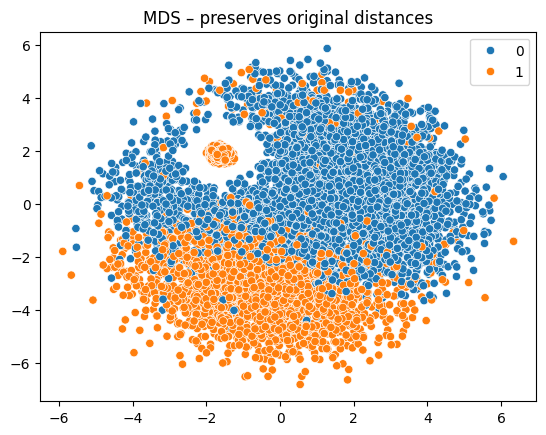

In [26]:
X_mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0).fit_transform(D)
sns.scatterplot(x=X_mds[:,0], y=X_mds[:,1], hue=y_all_1d)
plt.title("MDS – preserves original distances")

5. Now we have the train_ds and test_ds for training

In [27]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# Training Area

**Could modify the model as you wish here. Again, in default, influenciae relies on TensorFlow, so use the TensorFlow model if you only want to change the model. Remember: Store the InfluenceModel into the model_list with the loss function. The InfluenceModel will be used to obtain influence later. If you don't change the estimation methods, then the final output at this step shall always be the model_list**

**Input**:Train and Test Set from Data Construction Section   
**Output**: Model List  
**Guideline**: Input -> Define the Model and Hyperparameters -> Train the Model -> Output

Always remember to train the model, get the influence model and store that in model list, unless you wish to change the estimation methods.

The default code now use the train and test set generated from the last section to train the model. The default hyperparameters are: 500 Epochs, Simple FeedForward Neural Network, CategoricalCrossEntropy Loss function, SGD optimizer. Within each epoch, the current model will be turned into an Influence Model and stored inside a model list. After the training, the model list will be passed to next section for influence estimation.

In [28]:
from tensorflow.keras.regularizers import l2

1. **Could modify the model as you wish here as long as it is tensorflow.** Just remember: Store the InfluenceModel into the model_list with the loss function

In [29]:
seed_value = 41
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),  
    BatchNormalization(momentum=0.9),
    Dropout(0.0),
    Dense(8, activation='relu'),
    Dense(y_train.shape[1])
])
loss_fn = CategoricalCrossentropy(from_logits=True)
optimizer = SGD(learning_rate=0.001, momentum=0.9)
model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'])

epochs = 500
unreduced_loss_fn = CategoricalCrossentropy(from_logits=True, reduction=tf.keras.losses.Reduction.NONE)
model_list = []
model_list.append(InfluenceModel(model, start_layer=-1, loss_function=unreduced_loss_fn))
for i in range(epochs):
  model.fit(train_ds.batch(256), epochs=1, validation_data=test_ds.batch(256), verbose=2)
  model_list.append(InfluenceModel(model, start_layer=-1, loss_function=unreduced_loss_fn))
base_loss, acc = model.evaluate(test_ds.batch(32), verbose=2)
print(base_loss)

30/30 - 2s - loss: 0.5356 - accuracy: 0.7456 - val_loss: 0.4491 - val_accuracy: 0.7740 - 2s/epoch - 52ms/step
30/30 - 0s - loss: 0.4575 - accuracy: 0.7693 - val_loss: 0.3971 - val_accuracy: 0.8100 - 186ms/epoch - 6ms/step
30/30 - 0s - loss: 0.4206 - accuracy: 0.7897 - val_loss: 0.3708 - val_accuracy: 0.8180 - 205ms/epoch - 7ms/step
30/30 - 0s - loss: 0.3966 - accuracy: 0.8079 - val_loss: 0.3514 - val_accuracy: 0.8340 - 234ms/epoch - 8ms/step
30/30 - 0s - loss: 0.3776 - accuracy: 0.8189 - val_loss: 0.3356 - val_accuracy: 0.8380 - 255ms/epoch - 9ms/step
30/30 - 0s - loss: 0.3612 - accuracy: 0.8299 - val_loss: 0.3208 - val_accuracy: 0.8460 - 248ms/epoch - 8ms/step
30/30 - 0s - loss: 0.3462 - accuracy: 0.8428 - val_loss: 0.3065 - val_accuracy: 0.8540 - 167ms/epoch - 6ms/step
30/30 - 0s - loss: 0.3322 - accuracy: 0.8525 - val_loss: 0.2928 - val_accuracy: 0.8580 - 212ms/epoch - 7ms/step
30/30 - 0s - loss: 0.3188 - accuracy: 0.8596 - val_loss: 0.2797 - val_accuracy: 0.8720 - 155ms/epoch - 5ms

# Influence Estimation Area

**Again, you could use other influence analysis methods rather than IF/TC. You can also use any other Influence Function or TracIn implementation. Just Remember: 1. Make sure the package is unform throughout the framework. 2. Generate a Ranked influence list for each Influence Function and TracIn; Only the ranked influence list could be fed into the following analysis code.**

**The default code now use the model list, train set and test set to estimate the influence, and produce a ranked influence list for both IF and TC. The results are then saved in the root directory.**

**Input**:Model list from Training section, Train and Test Set from Data Construction Section   
**Output**: Two ranked Influence Lists for IF and TC.  
**Guideline**: Input -> Influence Estimation Methods -> Influence Matrix -> Output

1. Influence Function: Here we use the influenciae package. The following code will directly generate the influence list. If you wish to have the matrix, just use influence_matrix.

In [30]:
train_ids = []
test_ids = []
train_samples_np = np.array([x.numpy() for x, y in train_ds])
train_ids = [round(sample[-1] * 1e10) for sample in train_samples_np]

In [31]:
num_test_samples = len(test_ds)
num_train_samples = len(train_ids)
test_ids = []

influence_model = model_list[-1]
ihvp_calculator = ExactIHVP(influence_model, train_ds.batch(16))
influence_calculator = FirstOrderInfluenceCalculator(influence_model, train_ds, ihvp_calculator)

influence_matrix = np.zeros((num_test_samples, num_train_samples))

samples_to_explain = test_ds.take(num_test_samples).batch(1)
explanation_ds = influence_calculator.top_k(samples_to_explain, train_ds.batch(16), k=num_train_samples, order=ORDER.DESCENDING)
for test_idx,((sample, label), top_k_values, top_k_samples) in enumerate(explanation_ds.as_numpy_iterator()):
    test_sample_id = round(sample[0][-1] * 1e10)
    test_ids.append(test_sample_id)
    influential_ids = [round(s[-1] * 1e10) for s in top_k_samples[0]] 
    influence_scores = top_k_values[0]
    id_to_index = {train_id: idx for idx, train_id in enumerate(train_ids)}
    for inf_id, score in zip(influential_ids, influence_scores):
        if inf_id in id_to_index:
            influence_matrix[test_idx, id_to_index[inf_id]] = score

flattened_row = np.median(influence_matrix, axis=0).reshape(1, -1)
df = pd.DataFrame({'Train_ID': train_ids, 'Score': flattened_row.flatten()})
print(df)

      Train_ID     Score
0            1  0.012059
1            2  0.000620
2            3  0.000026
3            4  0.000011
4            5  0.002774
...        ...       ...
7495      7996  0.002346
7496      7997  0.000570
7497      7998 -0.000031
7498      7999  0.013029
7499      8000  0.019611

[7500 rows x 2 columns]


2. TracIn: Here we use the influenciae package. The following code will directly generate the influence list. If you wish to have the matrix, just use TracIn_matrix.

In [32]:
num_test_samples = len(test_ds)
num_train_samples = len(train_ids)
test_ids = []

TracIn_matrix = np.zeros((num_test_samples, num_train_samples))
influence_calculator = TracIn(
    model_list, 0.001
)
samples_to_explain = test_ds.take(num_test_samples).batch(1)
explanation_ds = influence_calculator.top_k(samples_to_explain, train_ds.batch(16), k=num_train_samples, order=ORDER.DESCENDING)
for test_idx,((sample, label), top_k_values, top_k_samples) in enumerate(explanation_ds.as_numpy_iterator()):
    test_sample_id = round(sample[0][-1] * 1e10)
    test_ids.append(test_sample_id)
    influential_ids = [round(s[-1] * 1e10) for s in top_k_samples[0]] 
    influence_scores = top_k_values[0]
    id_to_index = {train_id: idx for idx, train_id in enumerate(train_ids)}
    for inf_id, score in zip(influential_ids, influence_scores):
        if inf_id in id_to_index:
            TracIn_matrix[test_idx, id_to_index[inf_id]] = score

flattened_row = np.median(TracIn_matrix, axis=0).reshape(1, -1)
TracIn_df = pd.DataFrame({'Train_ID': train_ids, 'Score': flattened_row.flatten()})
print(TracIn_df)

      Train_ID         Score
0            1 -8.393707e-07
1            2 -2.480539e-08
2            3 -4.655853e-10
3            4 -5.908305e-10
4            5  7.388216e-07
...        ...           ...
7495      7996  6.881831e-07
7496      7997  1.295275e-07
7497      7998 -2.294018e-08
7498      7999  3.140258e-06
7499      8000  6.415744e-06

[7500 rows x 2 columns]


3. Here we turn both influence lists to the ranked influence lists and then store them for further processing.

In [33]:
df_sorted = df.sort_values(by="Score", ascending=False).reset_index(drop=True)

TracIn_sorted = TracIn_df.sort_values(by="Score", ascending=False).reset_index(drop=True)

In [34]:
TracIn_sorted.to_csv("TC_LargeSmall_Density_sep3_var41.csv",index = False)
df_sorted.to_csv("IF_LargeSmall_Density_sep3_var41.csv",index = False)